<a href="https://colab.research.google.com/github/tejaswipriya22/Tejaswi_Ml-on-big-data/blob/main/Week4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install pyspark

In [ ]:
from pyspark.sql import SparkSession

spark = SparkSession \
    .builder \
    .appName("Python Spark SQL basic example") \
    .config("spark.some.config.option", "some-value") \
    .getOrCreate()

In [ ]:
#raw_data = spark.read.format("csv").option("header","true").option("inferSchema", "true").load(r".\\diabetes.csv")
dataset = spark.read.csv('/content/titanic_synthetic_data.csv',inferSchema=True, header =True)

In [ ]:
# what are the columns in this dataset
dataset.columns

['Pclass',
 'Age',
 'SibSp',
 'Parch',
 'Fare',
 'Sex',
 'Survived',
 'Embarked_Q',
 'Embarked_S']

In [ ]:
dataset.describe().select("Summary","Pclass","Age","SibSp","Parch").show()

+-------+------------------+------------------+------------------+------------------+
|Summary|            Pclass|               Age|             SibSp|             Parch|
+-------+------------------+------------------+------------------+------------------+
|  count|           1000000|           1000000|           1000000|           1000000|
|   mean|          1.999411|         39.517847|          4.500906|          4.497493|
| stddev|0.8168263709530482|23.092708389398037|2.8714427426552285|2.8728101169393594|
|    min|                 1|                 0|                 0|                 0|
|    max|                 3|                79|                 9|                 9|
+-------+------------------+------------------+------------------+------------------+



In [ ]:
dataset.describe().select("Summary","Fare","Sex").show()

+-------+------------------+------------------+
|Summary|              Fare|               Sex|
+-------+------------------+------------------+
|  count|           1000000|           1000000|
|   mean| 254.9829083944402|           0.50082|
| stddev|141.53963219142216|0.4999995775993916|
|    min|10.000191449724019|                 0|
|    max| 499.9999338139367|                 1|
+-------+------------------+------------------+



In [ ]:
dataset.describe().select("Summary","Survived","Embarked_Q","Embarked_S").show()

+-------+------------------+-------------------+------------------+
|Summary|          Survived|         Embarked_Q|        Embarked_S|
+-------+------------------+-------------------+------------------+
|  count|           1000000|            1000000|           1000000|
|   mean|           0.49987|           0.332717|          0.333661|
| stddev|0.5000002331001768|0.47118639616145436|0.4715204761307361|
|    min|                 0|                  0|                 0|
|    max|                 1|                  1|                 1|
+-------+------------------+-------------------+------------------+



In [ ]:
from pyspark.sql.functions import col,isnan, when, count
dataset.select([count(when(isnan(c) | col(c).isNull(), c)).alias(c) for c in dataset.columns]
   ).show()

+------+---+-----+-----+----+---+--------+----------+----------+
|Pclass|Age|SibSp|Parch|Fare|Sex|Survived|Embarked_Q|Embarked_S|
+------+---+-----+-----+----+---+--------+----------+----------+
|     0|  0|    0|    0|   0|  0|       0|         0|         0|
+------+---+-----+-----+----+---+--------+----------+----------+



In [ ]:
# replace min value of zeros with Nan as data cleaning processs
import numpy as np
from pyspark.sql.functions import when
dataset=dataset.withColumn("Pclass",when(dataset.Pclass==0,np.nan).otherwise (dataset.Pclass))
dataset=dataset.withColumn("Age",when(dataset.Age==0,np.nan).otherwise(dataset.Age))
dataset=dataset.withColumn("Parch",when(dataset.Parch==0,np.nan).otherwise(dataset.Parch))
dataset=dataset.withColumn("Fare",when(dataset.Fare==0,np.nan).otherwise(dataset.Fare))
dataset=dataset.withColumn("Sex",when(dataset.Sex==0,np.nan).otherwise(dataset.Sex))
dataset=dataset.withColumn("Survived",when(dataset.Survived==0,np.nan).otherwise(dataset.Survived))
dataset.select("Pclass","Age","Parch","Fare","Sex","Survived").show(6)

+------+----+-----+------------------+---+--------+
|Pclass| Age|Parch|              Fare|Sex|Survived|
+------+----+-----+------------------+---+--------+
|   3.0|42.0|  7.0|397.00178367782024|NaN|     NaN|
|   1.0|52.0|  7.0|302.12770032784186|NaN|     NaN|
|   3.0|25.0|  8.0| 427.1058765283985|1.0|     1.0|
|   3.0|32.0|  7.0| 326.8049924602327|1.0|     NaN|
|   1.0|40.0|  5.0|17.718838497771657|NaN|     NaN|
|   1.0|20.0|  2.0|402.54904361394784|NaN|     NaN|
+------+----+-----+------------------+---+--------+
only showing top 6 rows


In [ ]:
# check again NAN values
from pyspark.sql.functions import col,isnan, when, count
dataset.select([count(when(isnan(c) , c)).alias(c) for c in dataset.columns]
   ).show()

+------+-----+-----+------+----+------+--------+----------+----------+
|Pclass|  Age|SibSp| Parch|Fare|   Sex|Survived|Embarked_Q|Embarked_S|
+------+-----+-----+------+----+------+--------+----------+----------+
|     0|12475|    0|100052|   0|499180|  500130|         0|         0|
+------+-----+-----+------+----+------+--------+----------+----------+



In [14]:
cols = dataset.columns
if "features" in cols: cols.remove("features")
if "Scaled_features" in cols: cols.remove("Scaled_features")
if "Survived" in cols: cols.remove("Survived")

# Drop existing vector columns to avoid duplication errors
dataset = dataset.drop("features", "Scaled_features")

from pyspark.ml.feature import VectorAssembler
assembler = VectorAssembler(inputCols=cols, outputCol="features")

dataset = assembler.transform(dataset)
dataset.select("features").show(truncate=False)

+-------------------------------------------------+
|features                                         |
+-------------------------------------------------+
|[3.0,42.0,6.0,7.0,397.00178367782024,0.0,0.0,1.0]|
|[1.0,52.0,6.0,7.0,302.12770032784186,0.0,1.0,0.0]|
|[3.0,25.0,3.0,8.0,427.1058765283985,1.0,1.0,0.0] |
|[3.0,32.0,9.0,7.0,326.8049924602327,1.0,0.0,0.0] |
|(8,[0,1,3,4],[1.0,40.0,5.0,17.718838497771657])  |
|[1.0,20.0,7.0,2.0,402.54904361394784,0.0,0.0,0.0]|
|[3.0,76.0,4.0,9.0,52.61038014285054,0.0,1.0,0.0] |
|[2.0,22.0,4.0,7.0,196.48213366632623,1.0,0.0,0.0]|
|[3.0,78.0,4.0,8.0,388.6259182464271,1.0,0.0,0.0] |
|[3.0,15.0,1.0,8.0,299.45900279822325,1.0,1.0,0.0]|
|[3.0,68.0,8.0,7.0,479.98134512112455,1.0,0.0,1.0]|
|[3.0,3.0,7.0,1.0,93.03405698775256,0.0,1.0,0.0]  |
|[1.0,63.0,4.0,0.0,84.64050143857706,1.0,0.0,0.0] |
|[3.0,0.0,9.0,8.0,296.7771124623517,0.0,0.0,1.0]  |
|[2.0,62.0,3.0,4.0,171.31211986091583,1.0,0.0,0.0]|
|[1.0,41.0,2.0,8.0,433.2922166813368,1.0,0.0,1.0] |
|[2.0,40.0,4

In [15]:
from pyspark.ml.feature import StandardScaler
standardscaler=StandardScaler().setInputCol("features").setOutputCol("Scaled_features")
dataset=standardscaler.fit(dataset).transform(dataset)
dataset.select("features","Scaled_features").show(6)

+--------------------+--------------------+
|            features|     Scaled_features|
+--------------------+--------------------+
|[3.0,42.0,6.0,7.0...|[3.67275115824148...|
|[1.0,52.0,6.0,7.0...|[1.22425038608049...|
|[3.0,25.0,3.0,8.0...|[3.67275115824148...|
|[3.0,32.0,9.0,7.0...|[3.67275115824148...|
|(8,[0,1,3,4],[1.0...|(8,[0,1,3,4],[1.2...|
|[1.0,20.0,7.0,2.0...|[1.22425038608049...|
+--------------------+--------------------+
only showing top 6 rows


In [13]:
train, test = dataset.randomSplit([0.8, 0.2], seed=12345)

In [16]:
dataset_size=float(train.select("Survived").count())
numPositives=train.select("Survived").where('Survived == 1').count()
per_ones=(float(numPositives)/float(dataset_size))*100
numNegatives=float(dataset_size-numPositives)
print('The number of ones are {}'.format(numPositives))
print('Percentage of ones are {}'.format(per_ones))

The number of ones are 399849
Percentage of ones are 49.965885404951486


In [17]:
BalancingRatio= numNegatives/dataset_size
print('BalancingRatio = {}'.format(BalancingRatio))

BalancingRatio = 0.5003411459504851


In [20]:
from pyspark.sql.functions import when

# Calculate class weights
train = train.withColumn("classWeights", when(train.Embarked_S == 1, BalancingRatio).otherwise(1 - BalancingRatio))
train.select("classWeights").show(6)

+-------------------+
|       classWeights|
+-------------------+
| 0.5003411459504851|
| 0.5003411459504851|
| 0.5003411459504851|
|0.49965885404951493|
|0.49965885404951493|
|0.49965885404951493|
+-------------------+
only showing top 6 rows


In [21]:
from pyspark.ml.feature import ChiSqSelector
css = ChiSqSelector(featuresCol='Scaled_features',outputCol='Aspect',labelCol='Survived',fpr=0.05)
train=css.fit(train).transform(train)
test=css.fit(test).transform(test)
test.select("Aspect").show(6,truncate=False)

+--------------------------------------------------------------------------------------------+
|Aspect                                                                                      |
+--------------------------------------------------------------------------------------------+
|(8,[0,4,6],[1.2242503860804963,2.0000016896038306,2.1223023587831746])                      |
|(8,[0,3,6],[1.2242503860804963,0.34809122750702337,2.1223023587831746])                     |
|(8,[0,3,5,7],[1.2242503860804963,0.34809122750702337,1.9999990675997195,2.120798672850694]) |
|(8,[0,3,4,5],[1.2242503860804963,0.34809122750702337,2.0000016896038306,1.9999990675997195])|
|(8,[0,3,5],[1.2242503860804963,0.34809122750702337,1.9999990675997195])                     |
|(8,[0,3,4],[1.2242503860804963,0.6961824550140467,2.0000016896038306])                      |
+--------------------------------------------------------------------------------------------+
only showing top 6 rows


In [22]:
from pyspark.ml.classification import LogisticRegression
lr = LogisticRegression(labelCol="Survived", featuresCol="Aspect",weightCol="classWeights",maxIter=10)
model=lr.fit(train)
predict_train=model.transform(train)
predict_test=model.transform(test)
predict_test.select("Survived","prediction").show(7)

+--------+----------+
|Survived|prediction|
+--------+----------+
|       0|       0.0|
|       0|       0.0|
|       1|       1.0|
|       1|       1.0|
|       1|       1.0|
|       0|       0.0|
|       0|       0.0|
+--------+----------+
only showing top 7 rows


In [23]:
from pyspark.ml.evaluation import BinaryClassificationEvaluator

evaluator=BinaryClassificationEvaluator(rawPredictionCol='prediction',labelCol="Survived")
auroc = evaluator.evaluate(predict_test, {evaluator.metricName: "areaUnderROC"})
print("Area under ROC Curve: {:.4f}".format(auroc))
predict_test.select("Survived","prediction","probability").show(9)

Area under ROC Curve: 1.0000
+--------+----------+--------------------+
|Survived|prediction|         probability|
+--------+----------+--------------------+
|       0|       0.0|[0.99960626966954...|
|       0|       0.0|[0.99960602019818...|
|       1|       1.0|[3.94836519579617...|
|       1|       1.0|[3.94424362144420...|
|       1|       1.0|[3.94180685989540...|
|       0|       0.0|[0.99960686332910...|
|       0|       0.0|[0.99960751634030...|
|       1|       1.0|[3.93805372368255...|
|       1|       1.0|[3.93556011412457...|
+--------+----------+--------------------+
only showing top 9 rows


In [24]:
pr = predict_test.toPandas()
TruePositive =0
FalsePositive=0
TrueNegative=0
FalseNegative=0
Postive=1.0
Negative=0.0
pos=0
Neg=0

print("Total",len(pr["Survived"]))
for lbl in range(len(pr["Survived"])):
  if  pr["prediction"][lbl]==Postive:
    pos+=1
    if pr["prediction"][lbl]==pr["Survived"][lbl]:
      TruePositive+=1
    else:
      FalsePositive+=1
  if  pr["prediction"][lbl]==Negative:
    Neg+=1
    if pr["prediction"][lbl]==pr["Survived"][lbl]:
      TrueNegative+=1
    else:
      FalseNegative+=1
#print("Total Positive & Negative predicted,  diabetes: ",pos,",Non Diabetes",Neg)
print("TruePostive",TruePositive,"FalsePostive",FalsePositive)
print("TrueNegative",TrueNegative,"FalseNegative",FalseNegative)

Total 199756
TruePostive 100021 FalsePostive 0
TrueNegative 99735 FalseNegative 0


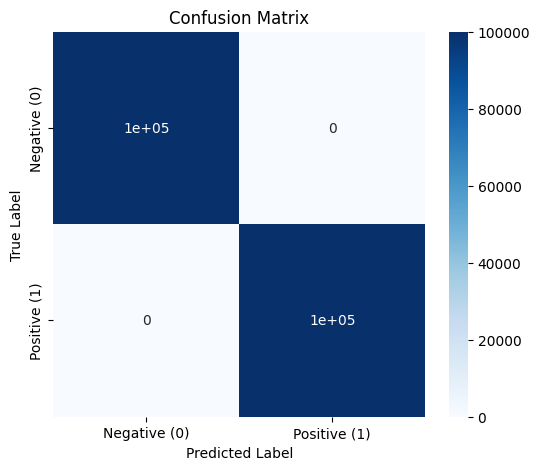

In [28]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

TN = TrueNegative
FP = FalsePositive
FN = FalseNegative
TP = TruePositive
conf_matrix = np.array([[TN, FP],[FN, TP]])
labels = ["Negative (0)", "Positive (1)"]

plt.figure(figsize=(6, 5))
sns.heatmap(conf_matrix, annot=True,  cmap="Blues",
            xticklabels=labels, yticklabels=labels)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

In [29]:
precision = TP / (TP + FP) if (TP + FP) > 0 else 0
recall = TP / (TP + FN) if (TP + FN) > 0 else 0
f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-score:  {f1_score:.4f}")

Precision: 1.0000
Recall:    1.0000
F1-score:  1.0000


In [30]:
from pyspark.sql.functions import col, when


total_count = train.count()
survived_distribution = train.groupBy('Survived').count().withColumn('percentage', (col('count') / total_count) * 100)
print("Class Distribution:")
survived_distribution.show()


count_0 = train.filter(col('Survived') == 0).count()
count_1 = train.filter(col('Survived') == 1).count()


weight_for_0 = total_count / (2.0 * count_0) if count_0 > 0 else 1.0
weight_for_1 = total_count / (2.0 * count_1) if count_1 > 0 else 1.0

train = train.withColumn("classWeights", when(col("Survived") == 1, weight_for_1).otherwise(weight_for_0))

print(f"Weight for Not Survived (0): {weight_for_0:.4f}")
print(f"Weight for Survived (1): {weight_for_1:.4f}")
train.select("Survived", "classWeights").show(5)

Class Distribution:
+--------+------+------------------+
|Survived| count|        percentage|
+--------+------+------------------+
|       1|399849|49.965885404951486|
|       0|400395| 50.03411459504851|
+--------+------+------------------+

Weight for Not Survived (0): 0.9993
Weight for Survived (1): 1.0007
+--------+------------------+
|Survived|      classWeights|
+--------+------------------+
|       0|0.9993181733038624|
|       0|0.9993181733038624|
|       1|1.0006827577410473|
|       1|1.0006827577410473|
|       1|1.0006827577410473|
+--------+------------------+
only showing top 5 rows


In [31]:
# Calculate Accuracy: (TP + TN) / Total
total_samples = TP + TN + FP + FN
accuracy = (TP + TN) / total_samples if total_samples > 0 else 0

print(f"Model Evaluation Results:")
print(f"-------------------------")
print(f"Total Samples: {total_samples}")
print(f"Accuracy:      {accuracy:.4f} ({accuracy*100:.2f}%)")

Model Evaluation Results:
-------------------------
Total Samples: 199756
Accuracy:      1.0000 (100.00%)
